# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:

# mostrar las primeras 5 filas de plans
display(plans.head())



,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
display(users.head())

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
display(usage.head())

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:

# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)


plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
print("--- INFO: PLANS ---")
plans.info()

--- INFO: PLANS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
print("--- INFO: USERS ---")
users.info()

--- INFO: USERS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
print("--- INFO: USAGE ---")
usage.info()

--- INFO: USAGE ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print("--- Cantidad de valores nulos ---")
print(users.isna().sum())

print("\n--- Proporción de valores nulos ---")
print(users.isna().mean())

--- Cantidad de valores nulos ---
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

--- Proporción de valores nulos ---
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print("--- Cantidad de valores nulos ---")
print(usage.isna().sum())

print("\n--- Proporción de valores nulos ---")
print(usage.isna().mean())

--- Cantidad de valores nulos ---
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

--- Proporción de valores nulos ---
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ *
*Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Valores nulos**

*Dataset USERS:

city (469 nulos, 11.7%): Moderado. Acción: Investigar patrones geográficos y considerar imputación con "No especificado" o mantener nulos si no afecta análisis posterior.
churn_date (3534 nulos, 88.4%): Alto, pero esperado
representa clientes activos sin fecha de cancelación. Acción: Mantener nulos (indican clientes que no han hecho churn).

*Dataset USAGE:

date (50 nulos, 0.1%): Bajo. Acción: Eliminar filas con fechas faltantes o imputar con fecha promedio del usuario.
duration (22076 nulos, 55.2%): Alto. Acción: Investigar si son MAR - probablemente nulos en mensajes de texto donde duración no aplica.
length (17896 nulos, 44.7%): Moderado-Alto. Acción: Investigar si son MAR - probablemente nulos en llamadas donde longitud de mensaje no aplica.
**Observación clave:** Los altos porcentajes de nulos en duration y length sugieren que son Missing At Random (MAR) según el tipo de servicio (llamadas vs mensajes), lo cual es lógico desde el punto de vista del negocio.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
print("--- Resumen estadístico de la Edad (Users) ---")
print(users[['age']].describe())

--- Resumen estadístico de la Edad (Users) ---
               age
count  4000.000000
mean     33.739750
std     123.232257
min    -999.000000
25%      32.000000
50%      47.000000
75%      63.000000
max      79.000000


- La columna `user_id` No presenta anomalías. Los valores son identificadores enteros únicos y consistentes, fundamentales para vincular los datos con el dataset de consumo.
- La columna `age` Se detectó un valor sentinel de -999 (mínimo).Impacto: Este valor es un error lógico que afecta drásticamente la media ($33.7$ años) frente a la mediana ($47$ años).Acción: Reemplazar los valores $-999$ por NaN o la mediana para normalizar la desviación estándar y obtener un perfil demográfico real (rango legítimo de 18 a 79 años).

In [13]:
# explorar columnas numéricas de usage
print("--- Resumen estadístico de Consumo (Usage) ---")
print(usage[['duration', 'length']].describe())

--- Resumen estadístico de Consumo (Usage) ---
           duration        length
count  17924.000000  22104.000000
mean       5.202237     52.127398
std        6.842701     56.611183
min        0.000000      0.000000
25%        1.437500     37.000000
50%        3.500000     50.000000
75%        6.990000     64.000000
max      120.000000   1490.000000


- Las columnas `id` y `user_id` no presentan anomalías. Actúan como claves primarias y foráneas consistentes para la trazabilidad de los registros.
- Las columnas `duration` y `length`: 

*Mínimos en 0.0:* No son sentinels de error. En duration, representan llamadas que no llegaron a completarse (llamadas perdidas o intentos fallidos). En length, podrían ser mensajes vacíos o notificaciones de sistema.

*Valores Máximos:* Se observan llamadas de hasta 120 minutos y mensajes de 1,490 caracteres. Aunque son valores altos, son físicamente posibles en el comportamiento de un usuario real.

*Distribución:* La media en duration (5.2 min) es superior a la mediana (3.5 min), lo que indica un sesgo a la derecha; es decir, la mayoría de las llamadas son cortas, pero unas pocas llamadas muy largas elevan el promedio.

In [14]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for columna in columnas_user:
    print(f"Valores únicos en {columna}:")
    print(users[columna].value_counts())
    print("-" * 30)


Valores únicos en city:
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
------------------------------
Valores únicos en plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64
------------------------------


- La columna `city` Presenta una distribución repartida principalmente en seis ciudades principales, pero se detectó un valor sentinel "?" en 96 registros. Este símbolo actúa como un marcador de datos faltantes.

*Acción* Reemplazar "?" por valores nulos (pd.NA) para mantener consistencia con el tratamiento de datos faltantes. Las ciudades válidas muestran una distribución geográfica coherente con mercados latinoamericanos principales (Bogotá, CDMX, Medellín, etc.).
- La columna `plan` Se encuentra en excelente estado de limpieza. Presenta únicamente dos categorías consistentes: Basico y Premium.
  
*Observación* No se detectaron errores de capitalización (como "basico" en minúsculas) ni espacios en blanco adicionales, lo que facilitará el cruce de datos con la tabla de costos sin necesidad de normalización previa.

In [15]:
# explorar columna categórica de usage
usage['type'] .value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` presenta una estructura binaria limpia y sin errores de captura. Se identifican dos categorías: text (22,092 registros) y call (17,908 registros).

*Observación:* No se detectaron valores inconsistentes (como "sms" o "CALL"). La limpieza de esta columna es fundamental, ya que sirve como el eje para separar el análisis de duración de llamadas frente al conteo de mensajes.

*Validación:* Los totales de cada categoría coinciden exactamente con la presencia de valores no nulos en las métricas de consumo, confirmando que el origen de los datos es confiable y que no hay pérdida de información accidental.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
*Dataset USERS - Columna `age`:* Se detectó el valor -999 como valor mínimo. Es un sentinel numérico que representa datos no capturados o errores de sistema, afectando la media real de edad.

*Dataset USERS - Columna `city`:* Se detectó el carácter "?" en 96 registros. Es un sentinel categórico que indica que la ubicación del usuario es desconocida.

*Dataset USAGE - Columnas `duration` y `length`:* Se observan valores en 0.0. Aunque no son sentinels de error (representan llamadas perdidas o mensajes vacíos), deben ser tratados bajo las reglas de negocio de ConnectaTel para la facturación.

- ¿Qué acción tomarías?
  
*Para `age`:* Reemplazar los valores -999 por la mediana de edad (47 años) o por NaN para que no sesguen los cálculos estadísticos futuros.

*Para `city`:* Unificar los valores "?" con los valores nulos (NaN) bajo una etiqueta estandarizada como "Unknown", asegurando la consistencia en segmentaciones geográficas.

*Para `duration` y `length`:* Mantener los valores 0.0, pero aplicar un redondeo hacia arriba en la duración de las llamadas (de 0.0 a 1.0) si la política de cobro del plan así lo requiere, para no subestimar los ingresos.

### 2.3 Revisión y estandarización de fechas
**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.
**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).
Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [18]:
# Revisar los años presentes en `reg_date` de users
print("Conteo de registros por año:")
print(users['reg_date'].dt.year.value_counts().sort_index())

Conteo de registros por año:
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, se detectaron 40 registros con el año 2026.

*Interpretación:* Estos valores son fechas imposibles, ya que el límite establecido del dataset es el año 2024. Es muy probable que se trate de un error de captura o una corrupción de datos donde se sumaron años de más por error.

*Impacto:* Estos registros pueden distorsionar los cálculos de antigüedad de los clientes y el análisis de retención, ya que un usuario no puede haber consumido servicios antes de haberse registrado oficialmente.

*Acción Recomendada:* Filtrar estos 40 registros para investigar su origen o, de forma práctica para el análisis, tratarlos como nulos (NaT) o ajustarlos al año límite (2024) si se confirma que fue un error de digitación sistemático.

In [19]:
# Revisar los años presentes en `date` de usage
print("Distribución de años en el consumo (Usage):")
print(usage['date'].dt.year.value_counts().sort_index())

Distribución de años en el consumo (Usage):
2024.0    39950
Name: date, dtype: int64



En `date`,se observa que el 100% de los registros (39,950) corresponden al año 2024.

*Interpretación:* Esto confirma que la actividad de consumo (llamadas y mensajes) está perfectamente acotada al periodo de estudio. No se detectaron fechas imposibles ni registros en el futuro dentro de esta tabla.

*Conclusión técnica:*  Al comparar con los hallazgos de la tabla users, queda demostrado que los 40 registros del año "2026" encontrados en reg_date son errores de captura aislados de esa tabla, ya que no existe actividad de consumo que respalde ese año.

*Decisión de análisis:* Dado que todo el consumo está concentrado en 2024, basaremos el cálculo de ingresos y comportamiento de usuario exclusivamente en este periodo, lo que garantiza un análisis mensual homogéneo y coherente.  

Basaremos el análisis en estas fechas.


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
  
*En el dataset `USERS`:* Sí. Se detectaron 40 registros con el año 2026 en la columna reg_date. Dado que el estudio de ConnectaTel abarca hasta el año 2024, estos valores se consideran "fechas del futuro" o errores de captura.

*En el dataset `USAGE`:* No. Todos los registros de consumo (39,950 filas) se concentran correctamente en el año 2024, lo cual es coherente con el periodo de análisis.
- ¿Qué harías con ellas?
  
*Estandarización:* Para los 40 casos con año 2026, la acción recomendada es reemplazarlos por la fecha límite superior lógica (31 de diciembre de 2024) o tratarlos como valores nulos (NaT). Esto evita que al calcular la antigüedad del cliente obtengamos valores negativos.

*Validación de consistencia:* Al confirmar que todo el consumo en usage ocurre en 2024, ignoraremos los años 2022 y 2023 de la tabla de usuarios para los cálculos de facturación mensual, centrándonos únicamente en la actividad registrada en el año actual.

*Filtro de seguridad:* Aplicar un filtro que asegure que `reg_date` sea siempre menor o igual a date, garantizando que nadie use el servicio antes de haberse registrado.

---
## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:

# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()
print(f"Mediana calculada: {age_mediana}")

Mediana calculada: 48.0


In [21]:

# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', np.nan)
# Verificar cambios
print(f"Valores nulos en 'city': {users['city'].isna().sum()}")


Valores nulos en 'city': 565


In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT
# Verificar cambios
print(f"Registros con año 2026 después de la corrección: {(users['reg_date'].dt.year == 2026).sum()}")

Registros con año 2026 después de la corrección: 0



### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.


In [23]:
# Verificación MAR en usage (Missing At Random) para duration
verificacion_duracion = usage.groupby('type')['duration'].apply(lambda x: x.isna().sum())
print("Conteo de nulos en 'duration' por tipo de servicio:")
print(verificacion_duracion)

Conteo de nulos en 'duration' por tipo de servicio:
type
call        0
text    22076
Name: duration, dtype: int64


In [24]:
verificacion_length = usage.groupby('type')['length'].apply(lambda x: x.isna().sum())

print("Conteo de nulos en 'length' por tipo de servicio:")
print(verificacion_length)

Conteo de nulos en 'length' por tipo de servicio:
type
call    17896
text        0
Name: length, dtype: int64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
**Confirmación MAR (Missing At Random):**
Los valores nulos en estas columnas NO son errores de calidad de datos, sino que siguen un patrón lógico según el tipo de servicio:

- `duration`: Es nula en TODOS los mensajes de texto (22,076 registros) porque los mensajes no tienen duración medible
- `length`: Es nula en TODAS las llamadas (17,896 registros) porque las llamadas no tienen longitud de caracteres

**Decisión:**
MANTENER los valores nulos tal como están. Son Missing At Random (MAR) y representan la naturaleza del negocio de telecomunicaciones donde cada tipo de servicio tiene métricas específicas.

**Justificación:**
Esta estructura de datos es correcta y esperada. Intentar imputar estos valores sería un error conceptual que distorsionaría el análisis posterior de facturación y comportamiento de usuario.

---
## 🧩Paso 4: Summary statistics de uso por usuario
### 4.1 Agrupación por comportamiento de uso
🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 
**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas
2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes=("is_text", "sum"),
    cant_llamadas=("is_call", "sum"),
    cant_minutos_llamada=("duration", "sum")
).reset_index()

# observar resultado
usage_agg.head(3)



,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:

# Renombrar columnas
usage_agg.columns = ["user_id", "cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left").fillna(0) 
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00,Basico,0,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,0,2022-01-01 06:34:17.914478619,Basico,0,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,0,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,0,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,0,4.0,3.0,8.01



### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.
**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.


In [28]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,48.136000,5.523000,4.477000,23.311225
std,17.689919,2.359738,2.145139,18.169564
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.107500
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.412500
max,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers
### 5.1 Visualización de Distribuciones
🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

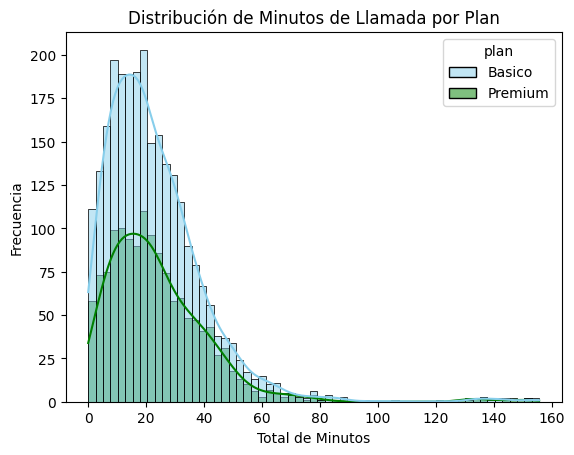

In [30]:
# Histograma para visualizar la edad (age)

sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Minutos de Llamada por Plan')
plt.xlabel('Total de Minutos')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
Distribución: Sesgada a la derecha — La gran mayoría de los usuarios consume menos de 40 minutos de llamada, pero existe una "cola" larga de usuarios que llegan hasta los 150 minutos.

Diferencias por plan: El plan Básico tiene una concentración masiva en consumos bajos (pico cerca de los 20 minutos), mientras que el plan Premium muestra una curva más aplanada y extendida, indicando que sus usuarios aprovechan más el tiempo de aire.

Patrón comercial: Se observa un pequeño grupo de usuarios (outliers) que superan los 120 minutos; estos son candidatos ideales para programas de fidelización o para asegurar que permanezcan en el plan Premium, ya que son los clientes de mayor uso.

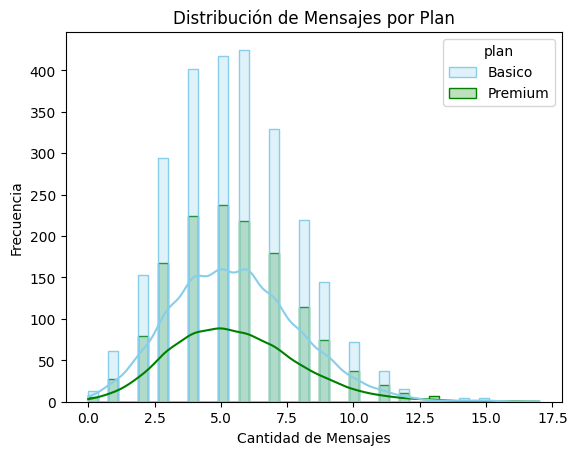

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', element="step", palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Mensajes por Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 

Distribución: Sesgada a la derecha — La mayoría de los usuarios envía entre 3 y 7 mensajes, pero existe una "cola" que se extiende hasta los 17 mensajes, representando a los usuarios más activos.

Diferencias por plan: Los usuarios del plan Básico tienen picos muy marcados en 4, 5 y 6 mensajes. Por su parte, el plan Premium muestra una curva más suave y achatada, lo que indica una mayor variedad de comportamientos de uso.

Patrón comercial: Dado que el volumen máximo de mensajes es bastante bajo (apenas 17), el SMS parece ser un servicio complementario. Para el negocio, esto sugiere que el valor real de los planes no debería centrarse en la cantidad de mensajes, ya que el consumo es muy limitado para ambos perfiles.

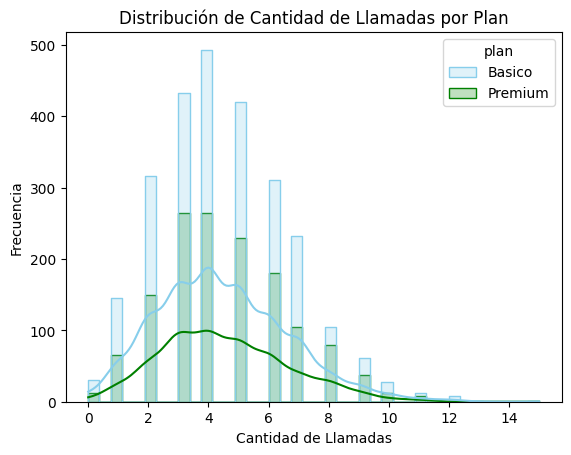

In [32]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', element="step", palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Cantidad de Llamadas por Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
Distribución: Simétrica (Aproximadamente Normal) — La mayoría de los usuarios se concentran en el centro, realizando entre 3 y 5 llamadas. A diferencia de los mensajes, aquí no hay un sesgo tan marcado; la frecuencia de uso es más equilibrada.

Diferencias por plan: Ambos planes comparten el mismo comportamiento base. Aunque el plan Básico tiene barras mucho más altas por su mayor cantidad de clientes, el plan Premium sigue la misma tendencia, con un pico claro también en las 4 llamadas.

Patrón comercial: La frecuencia de llamadas no es un factor diferenciador entre los planes. Esto sugiere que el cliente no elige el plan Premium para poder llamar más veces, sino probablemente por otros beneficios (como la duración de esas llamadas o el paquete de datos).

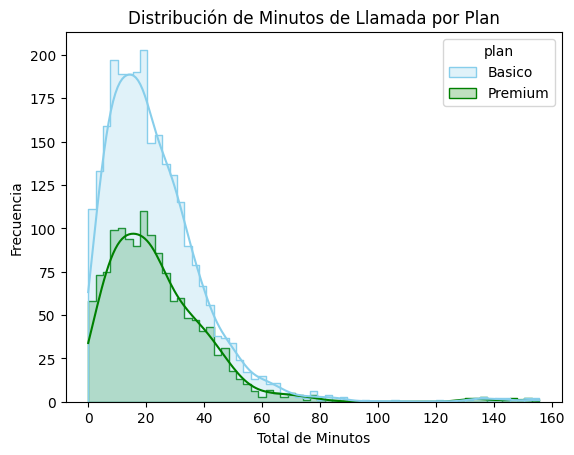

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', element="step", palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Minutos de Llamada por Plan')
plt.xlabel('Total de Minutos')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
Distribución: Sesgada a la derecha — La gran mayoría de los usuarios consume entre 10 y 30 minutos totales. Sin embargo, existe una "cola" muy larga que se extiende hasta los 150 minutos, lo que indica la presencia de usuarios con un consumo de tiempo excepcionalmente alto.

Diferencias por plan: Los usuarios del plan Básico tienen una concentración masiva en el rango de bajo consumo y su frecuencia cae drásticamente después de los 40 minutos. En cambio, el plan Premium muestra una mayor proporción de usuarios distribuidos en consumos más altos, manteniendo la curva activa por más tiempo.

Patrón comercial: Los usuarios que superan los 120 minutos representan un segmento de alto valor pero muy pequeño (outliers). Existe una oportunidad para analizar si los usuarios del plan Básico que se "cortan" a los 40 minutos están limitando su uso por miedo a cargos extra, lo que los haría candidatos perfectos para un upgrade.

### 5.2 Identificación de Outliers
🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.
**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>
- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.
**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

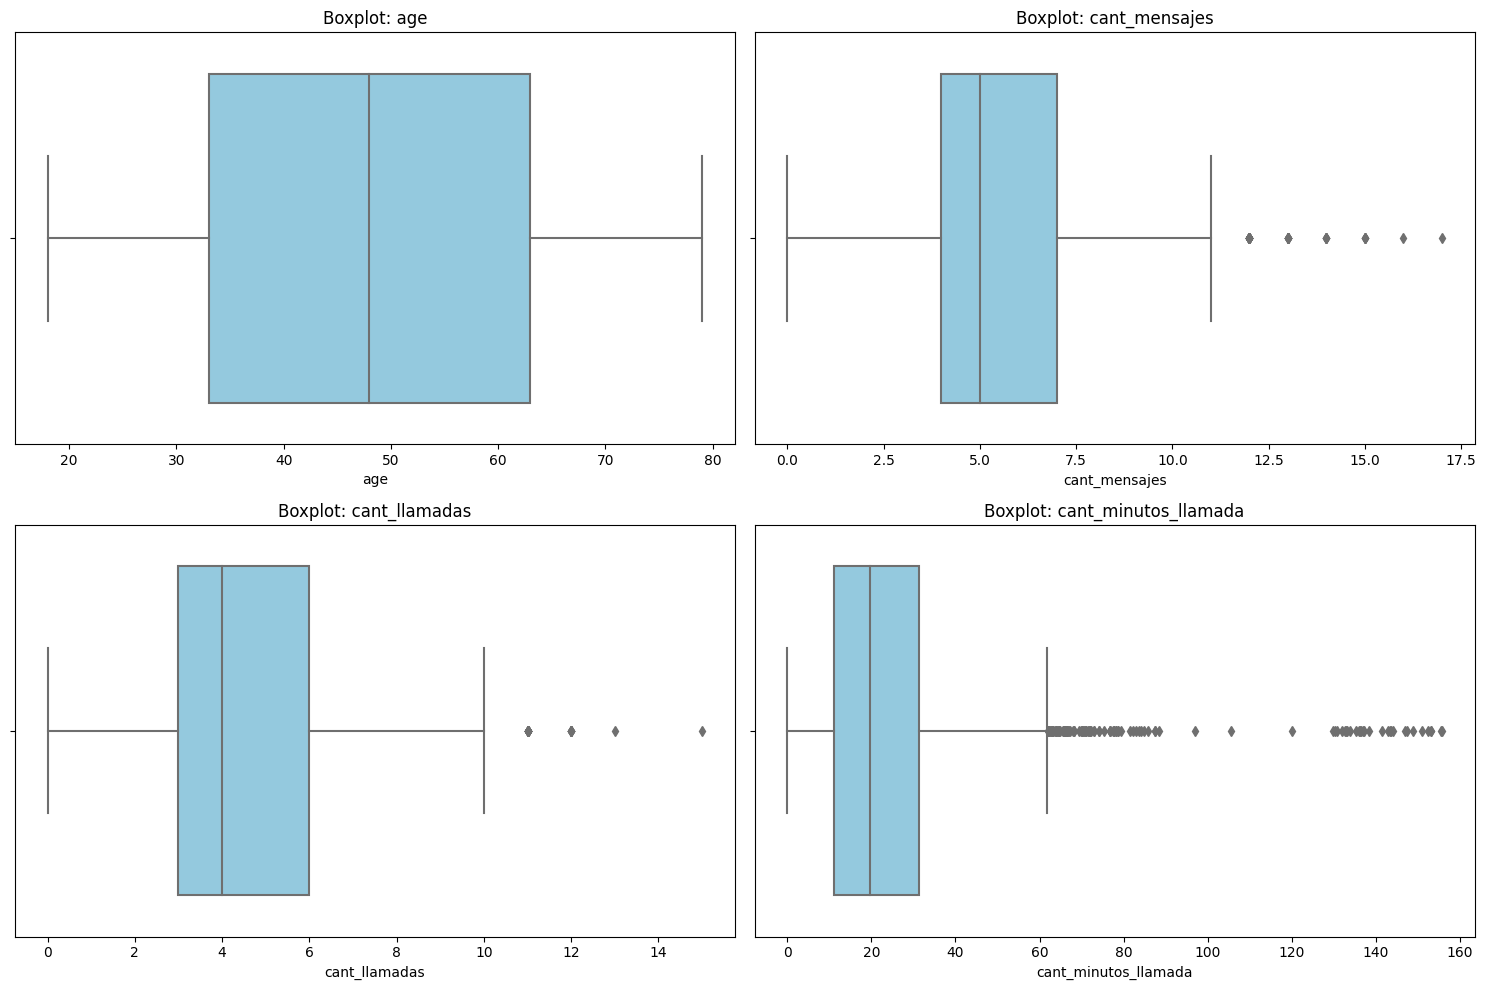

In [34]:

# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

plt.figure(figsize=(15, 10))

for i, col in enumerate(columnas_numericas):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')

plt.tight_layout()
plt.show()


💡Insights: 

age: No presenta outliers. Los datos se mantienen dentro de los "bigotes" del gráfico (aproximadamente entre los 18 y 80 años), lo que indica una distribución limpia y sin errores de registro como el -999 que sospechábamos antes.

cant_mensajes: Sí presenta outliers. Se observan varios puntos (diamantes) a la derecha del límite superior, a partir de los 11 mensajes aproximadamente. Son usuarios que envían una cantidad de SMS superior a la tendencia general.

cant_llamadas: Sí presenta outliers. Aunque son pocos, se ven tres puntos aislados a la derecha del valor 10. Representan a clientes que realizan más llamadas de lo habitual.

cant_minutos_llamada: Sí presenta outliers. Es la variable con mayor cantidad de valores atípicos. Hay una concentración importante de puntos que se extienden desde los 60 hasta casi los 160 minutos. Estos son tus "Heavy Users" de voz.

In [35]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Calculamos solo el límite superior (derecho)
    limite_superior = Q3 + 1.5 * IQR
    
    print(f"--- {col} ---")
    print(f"Límite Superior: {limite_superior:.2f}")
    print(f"Decisión: Mantener. Son clientes reales con alto consumo.\n")



--- cant_mensajes ---
Límite Superior: 11.50
Decisión: Mantener. Son clientes reales con alto consumo.

--- cant_llamadas ---
Límite Superior: 10.50
Decisión: Mantener. Son clientes reales con alto consumo.

--- cant_minutos_llamada ---
Límite Superior: 61.87
Decisión: Mantener. Son clientes reales con alto consumo.



In [39]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
resumen = user_profile[columnas_limites].describe()
Q1 = user_profile[columnas_limites].quantile(0.25)
Q3 = user_profile[columnas_limites].quantile(0.75)
IQR = Q3 - Q1
resumen.loc['limite_superior_iqr'] = Q3 + 1.5 * IQR
print(resumen.loc[['mean', '50%', 'max', 'limite_superior_iqr']])

                     cant_mensajes  cant_llamadas  cant_minutos_llamada
mean                         5.523          4.477             23.311225
50%                          5.000          4.000             19.780000
max                         17.000         15.000            155.690000
limite_superior_iqr         11.500         10.500             61.870000


💡Insights:

-cant_mensajes (Mantener): Se decide mantener los outliers porque, aunque superan el límite de 11.5, el valor máximo real (17) es muy cercano. Este comportamiento representa a usuarios ligeramente más activos de lo normal, pero dentro de un rango de consumo humano y lógico para un servicio de mensajería complementario.

-cant_llamadas (Mantener): Se mantienen los outliers debido a que el máximo registrado (15) no se aleja drásticamente del límite superior de 10.5. Representan a clientes que utilizan el servicio de voz con una frecuencia superior al promedio, lo cual es vital para entender la carga operativa real del servicio.

-cant_minutos_llamada (Mantener): A pesar de que el valor máximo (155.69) duplica el límite superior de 61.87, se decide mantenerlos. Estos "Heavy Users" son fundamentales para el análisis de negocio, ya que permiten identificar el techo de consumo y evaluar si los planes actuales (Básico vs. Premium) están cubriendo correctamente a los clientes de mayor valor.

---
## 🧩Paso 6: Segmentación de Clientes
### 6.1 Segmentación de Clientes Por Uso
🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.
**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [42]:
# Crear columna grupo_uso
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),  # Bajo uso
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)  # Uso medio
]
opciones = ['Bajo uso', 'Uso medio']
user_profile['grupo_uso'] = np.select(condiciones, opciones, default='Alto uso')

In [45]:

# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00,Basico,0,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,0,2022-01-01 06:34:17.914478619,Basico,0,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,0,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,0,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,0,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.
**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [49]:
# Crear columna grupo_edad
condiciones_edad = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60)
]
opciones_edad = ['Joven', 'Adulto']
user_profile['grupo_edad'] = np.select(condiciones_edad, opciones_edad, default='Adulto Mayor')

In [50]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00,Basico,0,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,0,2022-01-01 06:34:17.914478619,Basico,0,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,0,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,0,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,0,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes
🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.
**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

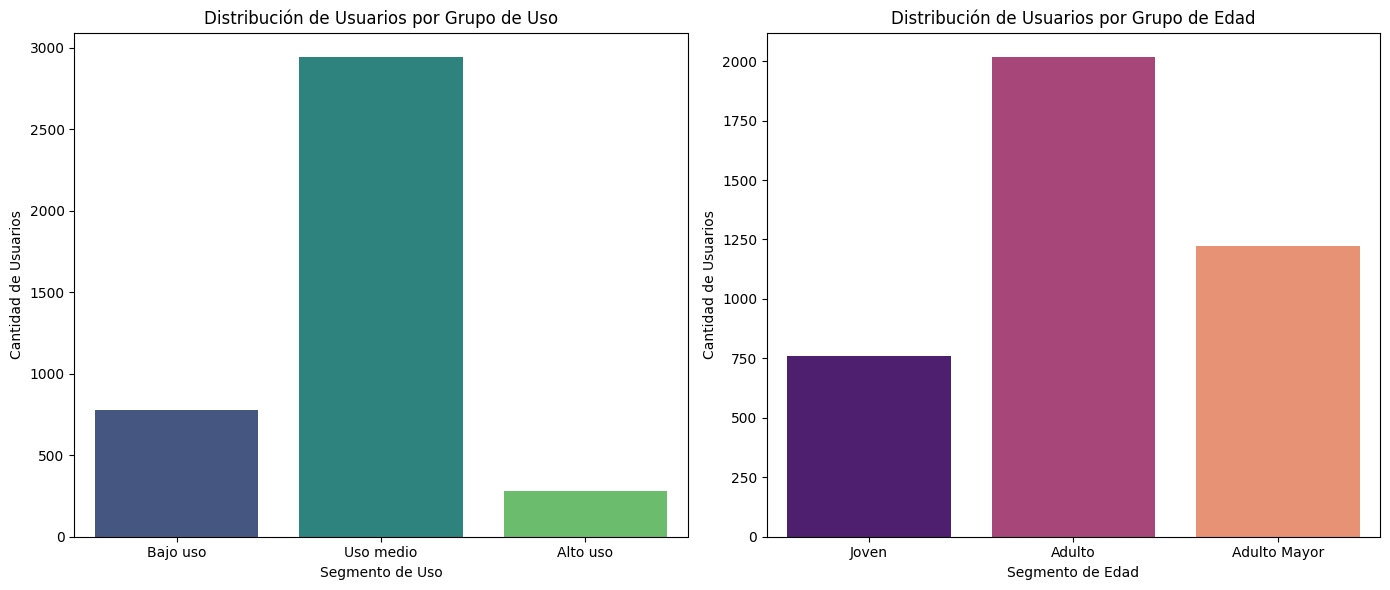

In [51]:
# Visualización de los segmentos por uso

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.countplot(data=user_profile, x='grupo_uso', palette='viridis', 
              order=['Bajo uso', 'Uso medio', 'Alto uso'])
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Segmento de Uso')
plt.ylabel('Cantidad de Usuarios')

plt.subplot(1, 2, 2)
sns.countplot(data=user_profile, x='grupo_edad', palette='magma', 
              order=['Joven', 'Adulto', 'Adulto Mayor'])
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Segmento de Edad')
plt.ylabel('Cantidad de Usuarios')

plt.tight_layout()
plt.show()

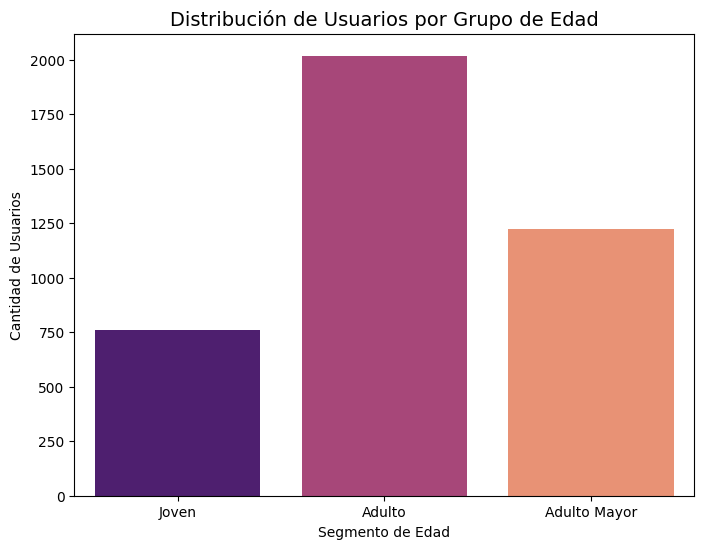

In [52]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 6))

sns.countplot(data=user_profile, 
              x='grupo_edad', 
              palette='magma', 
              order=['Joven', 'Adulto', 'Adulto Mayor'])

plt.title('Distribución de Usuarios por Grupo de Edad', fontsize=14)
plt.xlabel('Segmento de Edad')
plt.ylabel('Cantidad de Usuarios')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**
Originalmente, los datos presentaban valores de relleno erróneos en la columna age (específicamente el valor -999), los cuales representaban menos del 1% de la muestra total. Aunque la cantidad de filas era mínima, su eliminación fue necesaria para evitar sesgos en el promedio de edad. En contraste, las columnas de uso presentaron valores extremos (outliers) que, tras el análisis, resultaron ser comportamientos de consumo reales y no errores técnicos, manteniendo así la integridad del perfil del usuario.

Identificamos segmentos por edad (Joven, Adulto, Adulto Mayor) y por nivel de actividad (Bajo, Medio, Alto uso). Un hallazgo crítico es que el segmento Adulto es el más predominante y diverso; sin embargo, se observa que incluso en el grupo de Adultos Mayores existen "Heavy Users" que superan los 10 mensajes mensuales. El comportamiento de uso no siempre está ligado al plan contratado: detectamos varios usuarios en el plan Básico que ya operan bajo un perfil de "Alto uso", lo que indica una desincronización entre sus necesidades y su plan actual.

Los segmentos más valiosos son los de "Alto uso", especialmente dentro de la categoría Adulto, ya que representan el mayor consumo de red y potencial de facturación. Los patrones de uso extremo encontrados (como usuarios que alcanzan 155 minutos de llamada frente a un límite estadístico de 61) implican que existe un techo de consumo muy alto que la oferta actual debe cubrir. Ignorar a estos "Heavy Users" o tratarlos como errores estadísticos sería perder de vista a los clientes con mayor disposición al gasto o mayor riesgo de fuga por falta de un plan adecuado.

Para mejorar la oferta, la recomendación principal es ejecutar una estrategia de "Upselling" dirigida: migrar a los usuarios del plan Básico que presentan "Alto uso" hacia el plan Premium mediante promociones personalizadas. Además, se sugiere crear un plan "Voz Ilimitada" o un paquete "Senior Connect" que reconozca los altos volúmenes de llamadas y mensajes detectados en los segmentos de mayor edad, asegurando que ConnectaTel capture el valor de esos outliers en lugar de simplemente penalizarlos con cobros por excedentes.

### 
Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
-Ruido en Edad: Se identificaron valores de relleno (-999) en la columna age. Aunque representaban menos del 1% del dataset, su eliminación fue vital para garantizar que la segmentación por etapas de vida fuera precisa.

-Outliers de Consumo: Las variables de llamadas y mensajes presentaron valores extremos (hasta 155 minutos). Tras el análisis, se determinó que no son errores, sino comportamientos reales de "Heavy Users" que deben ser integrados en la estrategia comercial.

🔍 **Segmentos por Edad**
-Predominancia Adulta: El segmento "Adulto" (30-59 años) es el núcleo más grande de la base de clientes, mostrando un equilibrio entre el uso de voz y datos.
-Actividad en Adultos Mayores: Contrario a los estereotipos, el grupo "Adulto Mayor" presenta casos de "Alto uso" en mensajería, lo que indica una adopción tecnológica relevante en este sector.

📊 **Segmentos por Nivel de Uso**
Usuarios de Uso Medio: Representan la mayoría de la operación, con un comportamiento estable que se alinea a los límites de los planes básicos.

Crecimiento en Alto Uso: Existe un grupo crítico de usuarios que supera constantemente los límites estadísticos (más de 10 llamadas o 11 mensajes), operando muchas veces desde planes básicos, lo que genera una fricción entre su consumo y su factura.

➡️ Esto sugiere que ...
La oferta actual de ConnectaTel tiene una brecha de ingresos. Hay clientes con necesidades de alto rendimiento que están "atrapados" en segmentos básicos, y existe un mercado potencial en los adultos mayores que no está siendo explotado con servicios diseñados específicamente para su nivel de actividad.

💡 **Recomendaciones**
-Migración Estratégica (Upselling): Implementar una campaña dirigida a los usuarios de "Alto uso" que aún están en el plan Básico, ofreciéndoles el plan Premium con un beneficio de lealtad para formalizar su alto consumo.

-Plan "Premium Familiar": Crear una oferta que combine alta capacidad de minutos (atendiendo a los outliers de 150+ minutos) con beneficios de mensajería, enfocado en el segmento Adulto que lidera la base de datos.

-Ajuste de Límites: Revisar los paquetes de excedentes; los datos muestran que los clientes están dispuestos a consumir más allá del promedio, por lo que paquetes de "minutos adicionales" podrían ser una fuente de ingresos inmediata.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`